# Статистические модели прогнозирования

**Store Item Demand Forecasting — Task 2/3**

На этом этапе сравниваются пять статистических моделей на одной и той же rolling-origin схеме:

| Модель | Роль |
|---|---|
| `Naive` | базовый прогноз последним значением |
| `SeasonalNaive` | сезонный baseline с периодом 7 |
| `AutoARIMA` | автоматический ARIMA-подход |
| `AutoETS` | экспоненциальное сглаживание |
| `AutoTheta` | Theta method |

**Цель:** получить честно сопоставимые out-of-sample метрики и выбрать статистический benchmark для сравнения с ML/DL-моделями в Task 3.


In [ ]:
%pip -q install -U statsforecast statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 864.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 1.8 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, AutoETS, AutoTheta
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

PROJECT_DIR = Path('/content/drive/MyDrive/time_series_final_project')
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
FIGURES_DIR = PROJECT_DIR / 'reports' / 'figures'
RESULTS_DIR = PROJECT_DIR / 'results'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PREPARED_PATH = PROCESSED_DIR / 'store_item_sales_prepared.csv'
print('Prepared exists:', PREPARED_PATH.exists())

Mounted at /content/drive
Prepared exists: True


In [ ]:
df = pd.read_csv(PREPARED_PATH, parse_dates=['ds'])
required = {'unique_id', 'ds', 'y'}
assert required.issubset(df.columns), f'Missing columns: {required - set(df.columns)}'

df_stats = df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
assert not df_stats.duplicated(['unique_id', 'ds']).any(), 'Duplicate (unique_id, ds) keys found'

print('rows:', len(df_stats))
print('series:', df_stats['unique_id'].nunique())
print('period:', df_stats['ds'].min().date(), '—', df_stats['ds'].max().date())

rows: 913000
series: 500
period: 2013-01-01 — 2017-12-31


## 1. Единая схема backtesting

Используется одна конфигурация для всех пяти моделей:

| Параметр | Значение |
|---|---:|
| Горизонт `h` | 28 дней |
| Число окон | 3 |
| `step_size` | 28 дней |
| Перекрытие test-окон | нет |
| `refit` | `False` |
| Число рядов | 500 |

Для **каждой модели** ожидается:

`500 × 3 × 28 = 42 000` out-of-sample прогнозных точек.

Для пяти моделей это соответствует 210 000 отдельных model-predictions; после объединения моделей в wide-формат таблица содержит 42 000 строк.

`refit=False` означает, что модель не переобучается с нуля для каждого следующего CV-окна. Такая схема существенно снижает вычислительную стоимость; её ограничение явно фиксируется и далее сохраняется неизменной для сопоставления с Task 3.


In [ ]:
import os
import time
import pandas as pd
from tqdm.auto import tqdm

# ============================================================
# ОПТИМИЗАЦИЯ CPU ДЛЯ COLAB
# Заставляем NumPy/SciPy использовать все доступные ядра.
# ============================================================
n_cpus = os.cpu_count() or 1
os.environ["OMP_NUM_THREADS"] = str(n_cpus)
os.environ["MKL_NUM_THREADS"] = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cpus)
print(f"🔧 Доступно vCPU: {n_cpus}")

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive, AutoARIMA, AutoETS, AutoTheta
)

# ============================================================
# ПАРАМЕТРЫ
# ============================================================
SEASON_LENGTH = 7
HORIZON       = 28
N_WINDOWS     = 3
STEP_SIZE     = 28
REFIT         = False   # Без полного переобучения на каждом окне; та же схема используется в Task 3
SAVE_CHUNKS   = True   # Сохранять промежуточные результаты по моделям
OUTPUT_DIR    = "cv_chunks"

# ============================================================
# ПРОВЕРКИ ВХОДНЫХ ДАННЫХ
# ============================================================
assert {'unique_id', 'ds', 'y'}.issubset(df_stats.columns), \
    "df_stats должен содержать столбцы unique_id, ds, y"
assert pd.api.types.is_datetime64_any_dtype(df_stats['ds']), \
    "Столбец ds должен быть datetime64"
assert df_stats['y'].notna().all(), "Столбец y содержит NaN"

n_series = df_stats['unique_id'].nunique()
print(f"📊 Рядов: {n_series}")

# Проверка минимальной длины ряда
min_len = df_stats.groupby('unique_id').size().min()
required = N_WINDOWS * STEP_SIZE + HORIZON
print(f"📏 Мин. длина ряда: {min_len} | требуется: >{required}")
assert min_len > required, \
    f"Ряд слишком короткий: {min_len} <= {required}. CV невозможна."

# ============================================================
# МОДЕЛИ
# ============================================================
models = [
    ("Naive",         Naive()),
    ("SeasonalNaive", SeasonalNaive(season_length=SEASON_LENGTH)),

    # AutoARIMA с ограничениями — значительно быстрее без потери качества.
    # stepwise=True использует жадный поиск вместо полного перебора.
    ("AutoARIMA", AutoARIMA(
        season_length=SEASON_LENGTH,
        max_p=2, max_q=2,
        max_P=1, max_Q=1,
        max_d=1, max_D=1,
        stepwise=True,
    )),

    ("AutoETS",   AutoETS(season_length=SEASON_LENGTH)),
    ("AutoTheta", AutoTheta(season_length=SEASON_LENGTH)),
]

# ============================================================
# КРОСС-ВАЛИДАЦИЯ С ПРОГРЕСС-БАРОМ
# ============================================================
if SAVE_CHUNKS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

all_cv   = []
timings  = {}

total_models = len(models)
print(f"\n🚀 Запуск CV: {total_models} моделей × {n_series} рядов × "
      f"{N_WINDOWS} окон, горизонт={HORIZON}, refit={REFIT}")
print(f"{'='*60}")

for idx, (name, model) in enumerate(tqdm(models, desc="Модели", unit="model"), 1):
    t0 = time.time()
    tqdm.write(f"\n▶ [{idx}/{total_models}] Запуск {name}...")

    try:
        sf = StatsForecast(models=[model], freq='D', n_jobs=-1)
        cv = sf.cross_validation(
            df=df_stats,
            h=HORIZON,
            n_windows=N_WINDOWS,
            step_size=STEP_SIZE,
            refit=REFIT,
        )
        cv['model'] = name
        all_cv.append(cv)

        elapsed = time.time() - t0
        timings[name] = elapsed
        tqdm.write(f"✅ {name}: {elapsed:.1f} сек ({elapsed/60:.1f} мин) "
                   f"| строк: {len(cv):,}")

        # Сохраняем чанк, чтобы не потерять при падении сессии
        if SAVE_CHUNKS:
            chunk_path = os.path.join(OUTPUT_DIR, f"cv_{name}.parquet")
            cv.to_parquet(chunk_path, index=False)
            tqdm.write(f"   💾 Сохранено: {chunk_path}")

    except Exception as e:
        tqdm.write(f"❌ {name}: ОШИБКА — {e}")
        timings[name] = float('nan')

# ============================================================
# ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================
print(f"\n{'='*60}")
print("🔄 Объединение результатов...")

cv_df = pd.concat(all_cv, ignore_index=True)
cv_df = cv_df.sort_values(['unique_id', 'ds', 'cutoff', 'model']).reset_index(drop=True)

# ============================================================
# ПРОВЕРКИ РЕЗУЛЬТАТА
# ============================================================
n_models      = len([m for m in timings if not pd.isna(timings[m])])
expected_total = n_series * N_WINDOWS * HORIZON * n_models

print(f"\n{'='*60}")
print(f"📊 CV rows: {len(cv_df):,} | expected: {expected_total:,}")

if len(cv_df) != expected_total:
    print(f"⚠️  Несовпадение! Разница: {expected_total - len(cv_df):,}")
    print(f"   Возможно, часть моделей упала с ошибкой.")
else:
    print("✅ Число строк совпадает")

# Уникальность комбинаций
dups = cv_df.duplicated(['unique_id', 'ds', 'cutoff', 'model']).sum()
assert dups == 0, f"Найдено {dups} дубликатов по (unique_id, ds, cutoff, model)"
print("✅ Дубликатов нет")

# Проверка отсутствия утечки
leaks = (cv_df['ds'] <= cv_df['cutoff']).sum()
assert leaks == 0, f"Найдено {leaks} строк с ds <= cutoff (утечка данных)"
print("✅ Утечек данных нет")

print(f"{'='*60}")

# ============================================================
# СВОДКА ПО ВРЕМЕНИ
# ============================================================
print("\n⏱  Время по моделям:")
print(f"   {'Модель':15s} {'Секунды':>10s} {'Минуты':>10s}")
print(f"   {'-'*15} {'-'*10} {'-'*10}")

for name, sec in timings.items():
    if pd.isna(sec):
        print(f"   {name:15s} {'FAILED':>10s} {'—':>10s}")
    else:
        print(f"   {name:15s} {sec:10.1f} {sec/60:10.1f}")

total_time = sum(s for s in timings.values() if not pd.isna(s))
print(f"   {'-'*15} {'-'*10} {'-'*10}")
print(f"   {'ИТОГО':15s} {total_time:10.1f} {total_time/60:10.1f}")

# ============================================================
# ПРОСМОТР РЕЗУЛЬТАТОВ
# ============================================================
print(f"\n{'='*60}")
print("📋 Пример результатов:")
display(cv_df.head(10))

print(f"\n📈 Статистика:")
print(f"   Уникальных моделей: {cv_df['model'].nunique()}")
print(f"   Уникальных рядов:   {cv_df['unique_id'].nunique()}")
print(f"   Уникальных cutoff:  {cv_df['cutoff'].nunique()}")
print(f"   Модели: {sorted(cv_df['model'].unique().tolist())}")

🔧 Доступно vCPU: 2
📊 Рядов: 500
📏 Мин. длина ряда: 1826 | требуется: >112

🚀 Запуск CV: 5 моделей × 500 рядов × 3 окон, горизонт=28, refit=False


Модели:   0%|          | 0/5 [00:00<?, ?model/s]


▶ [1/5] Запуск Naive...
✅ Naive: 0.4 сек (0.0 мин) | строк: 42,000
   💾 Сохранено: cv_chunks/cv_Naive.parquet

▶ [2/5] Запуск SeasonalNaive...
✅ SeasonalNaive: 0.4 сек (0.0 мин) | строк: 42,000
   💾 Сохранено: cv_chunks/cv_SeasonalNaive.parquet

▶ [3/5] Запуск AutoARIMA...
✅ AutoARIMA: 2567.0 сек (42.8 мин) | строк: 42,000
   💾 Сохранено: cv_chunks/cv_AutoARIMA.parquet

▶ [4/5] Запуск AutoETS...
✅ AutoETS: 1113.7 сек (18.6 мин) | строк: 42,000
   💾 Сохранено: cv_chunks/cv_AutoETS.parquet

▶ [5/5] Запуск AutoTheta...
✅ AutoTheta: 1061.8 сек (17.7 мин) | строк: 42,000
   💾 Сохранено: cv_chunks/cv_AutoTheta.parquet

🔄 Объединение результатов...

📊 CV rows: 210,000 | expected: 210,000
✅ Число строк совпадает
✅ Дубликатов нет
✅ Утечек данных нет

⏱  Время по моделям:
   Модель             Секунды     Минуты
   --------------- ---------- ----------
   Naive                  0.4        0.0
   SeasonalNaive          0.4        0.0
   AutoARIMA           2567.0       42.8
   AutoETS           

,unique_id,ds,cutoff,y,Naive,model,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta
0,store_10_item_1,2017-10-09,2017-10-08,21.0,NaN,AutoARIMA,NaN,25.842943,NaN,NaN
1,store_10_item_1,2017-10-09,2017-10-08,21.0,NaN,AutoETS,NaN,NaN,23.286858,NaN
2,store_10_item_1,2017-10-09,2017-10-08,21.0,NaN,AutoTheta,NaN,NaN,NaN,22.320868
3,store_10_item_1,2017-10-09,2017-10-08,21.0,31.0,Naive,NaN,NaN,NaN,NaN
4,store_10_item_1,2017-10-09,2017-10-08,21.0,NaN,SeasonalNaive,17.0,NaN,NaN,NaN
5,store_10_item_1,2017-10-10,2017-10-08,31.0,NaN,AutoARIMA,NaN,28.458712,NaN,NaN
6,store_10_item_1,2017-10-10,2017-10-08,31.0,NaN,AutoETS,NaN,NaN,26.926573,NaN
7,store_10_item_1,2017-10-10,2017-10-08,31.0,NaN,AutoTheta,NaN,NaN,NaN,26.467453
8,store_10_item_1,2017-10-10,2017-10-08,31.0,31.0,Naive,NaN,NaN,NaN,NaN
9,store_10_item_1,2017-10-10,2017-10-08,31.0,NaN,SeasonalNaive,28.0,NaN,NaN,NaN



📈 Статистика:
   Уникальных моделей: 5
   Уникальных рядов:   500
   Уникальных cutoff:  3
   Модели: ['AutoARIMA', 'AutoETS', 'AutoTheta', 'Naive', 'SeasonalNaive']


In [ ]:
import pandas as pd
for f in ['cv_chunks/cv_Naive.parquet', 'cv_chunks/cv_AutoARIMA.parquet']:
    chunk = pd.read_parquet(f)
    print(f"\n{f}")
    print(f"  Столбцы: {chunk.columns.tolist()}")
    print(f"  Форма:   {chunk.shape}")
    print(chunk.head(2))


cv_chunks/cv_Naive.parquet
  Столбцы: ['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'model']
  Форма:   (42000, 6)
         unique_id         ds     cutoff     y  Naive  model
0  store_10_item_1 2017-10-09 2017-10-08  21.0   31.0  Naive
1  store_10_item_1 2017-10-10 2017-10-08  31.0   31.0  Naive

cv_chunks/cv_AutoARIMA.parquet
  Столбцы: ['unique_id', 'ds', 'cutoff', 'y', 'AutoARIMA', 'model']
  Форма:   (42000, 6)
         unique_id         ds     cutoff     y  AutoARIMA      model
0  store_10_item_1 2017-10-09 2017-10-08  21.0  25.842943  AutoARIMA
1  store_10_item_1 2017-10-10 2017-10-08  31.0  28.458712  AutoARIMA


In [ ]:
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# Папка для результатов
# ============================================================
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# ============================================================
# ПЕРЕСБОРКА cv_df ИЗ ЧАНКОВ (wide-формат)
# ============================================================
KEY_COLS = ['unique_id', 'ds', 'cutoff', 'y']

chunks = sorted(glob.glob('cv_chunks/cv_*.parquet'))
print(f"Найдено чанков: {len(chunks)}")
for f in chunks:
    print(f"  ✓ {f}")

assert len(chunks) == 5, f"Ожидалось 5 чанков, найдено {len(chunks)}"

def clean_chunk(path):
    """Загружает чанк и убирает лишний столбец 'model'."""
    df = pd.read_parquet(path)
    if 'model' in df.columns:
        df = df.drop(columns=['model'])
    return df

# Первый чанк — база, затем merge остальных
cv_df = clean_chunk(chunks[0])
for f in chunks[1:]:
    cv_df = cv_df.merge(clean_chunk(f), on=KEY_COLS, how='outer')

cv_df = cv_df.sort_values(['unique_id', 'ds', 'cutoff']).reset_index(drop=True)

# ============================================================
# Проверки формата
# ============================================================
print(f"\nФорма cv_df: {cv_df.shape}")
print(f"Столбцы:     {cv_df.columns.tolist()}")

model_cols = [c for c in cv_df.columns if c not in KEY_COLS]
print(f"Модели:      {model_cols}")

assert len(model_cols) == 5, f"Ожидалось 5 моделей, найдено: {model_cols}"
assert len(cv_df) == 42_000, f"Ожидалось 42000 строк, найдено: {len(cv_df)}"
assert cv_df[model_cols].isna().sum().sum() == 0, "Есть NaN в столбцах моделей"

print("✅ cv_df собран в wide-формат без NaN")

# ============================================================
# Метрики
# ============================================================
def smape_pct(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    ratio = np.divide(
        np.abs(y_true - y_pred),
        denom,
        out=np.zeros_like(denom, dtype=float),
        where=denom != 0,
    )
    return 100.0 * np.mean(ratio)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'sMAPE_%': smape_pct(y_true, y_pred),
        'MAE':     np.mean(np.abs(y_true - y_pred)),
        'RMSE':    np.sqrt(np.mean((y_true - y_pred) ** 2)),
    }

metrics_df = pd.DataFrame([
    {'model': m, **calc_metrics(cv_df['y'], cv_df[m])}
    for m in model_cols
]).sort_values('sMAPE_%').reset_index(drop=True)

print("\n📊 Метрики по моделям:")
display(metrics_df)

# ============================================================
# Сохранение
# ============================================================
metrics_df.to_csv(RESULTS_DIR / 'task2_metrics.csv', index=False)
cv_df.to_parquet(RESULTS_DIR / 'task2_cv_predictions.parquet', index=False)

config = {
    'horizon':       HORIZON,
    'n_windows':     N_WINDOWS,
    'step_size':     STEP_SIZE,
    'season_length': SEASON_LENGTH,
    'n_series':      int(df_stats['unique_id'].nunique()),
    'models':        model_cols,
}
(RESULTS_DIR / 'task2_cv_config.json').write_text(
    json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8'
)

print(f"\n✅ Всё сохранено в: {RESULTS_DIR.resolve()}")

Найдено чанков: 5
  ✓ cv_chunks/cv_AutoARIMA.parquet
  ✓ cv_chunks/cv_AutoETS.parquet
  ✓ cv_chunks/cv_AutoTheta.parquet
  ✓ cv_chunks/cv_Naive.parquet
  ✓ cv_chunks/cv_SeasonalNaive.parquet

Форма cv_df: (42000, 9)
Столбцы:     ['unique_id', 'ds', 'cutoff', 'y', 'AutoARIMA', 'AutoETS', 'AutoTheta', 'Naive', 'SeasonalNaive']
Модели:      ['AutoARIMA', 'AutoETS', 'AutoTheta', 'Naive', 'SeasonalNaive']
✅ cv_df собран в wide-формат без NaN

📊 Метрики по моделям:


,model,sMAPE_%,MAE,RMSE
0,AutoETS,16.978328,8.329015,10.888117
1,AutoTheta,17.031804,8.361615,10.931076
2,AutoARIMA,18.650644,9.092208,11.764877
3,SeasonalNaive,21.067066,10.499119,13.982316
4,Naive,25.089491,13.929262,18.250364



✅ Всё сохранено в: /content/results


## 2. Качество по отдельным временным рядам

Средняя sMAPE по всем 500 сериям может скрывать сильную неоднородность. Поэтому дополнительно рассчитывается sMAPE отдельно для каждого `unique_id`, после чего сравниваются среднее, медиана, стандартное отклонение и диапазон ошибки по сериям.

Это позволяет проверить, является ли результат модели устойчивым по панели, а не только хорошим в среднем.


In [ ]:
per_series_rows = []
for uid, g in cv_df.groupby('unique_id', sort=False):
    for m in model_cols:
        per_series_rows.append({'unique_id': uid, 'model': m, 'sMAPE_%': smape_pct(g['y'], g[m])})
per_series = pd.DataFrame(per_series_rows)
per_series_summary = (
    per_series.groupby('model')['sMAPE_%']
      .agg(['mean', 'median', 'std', 'min', 'max'])
      .sort_values('mean')
)
display(per_series_summary)
per_series.to_csv(RESULTS_DIR / 'task2_per_series_smape.csv', index=False)

,mean,median,std,min,max
model,,,,,
AutoETS,16.978328,16.464570,3.555200,9.876676,28.742561
AutoTheta,17.031804,16.538978,3.536379,10.321857,28.775736
AutoARIMA,18.650644,18.814739,4.122409,9.503797,29.955014
SeasonalNaive,21.067066,20.180225,4.505886,12.533690,35.999122
Naive,25.089491,24.284856,5.665556,13.890670,50.618399


## 3. Диагностика out-of-sample остатков

Диагностика выполняется **на одном временном ряду** (`store_1_item_1`) и только на его out-of-sample прогнозах лучшей статистической модели.

Для остатков анализируются:
- среднее смещение;
- Ljung–Box test на остаточную автокорреляцию;
- Jarque–Bera test как описательная проверка формы распределения;
- временной график и гистограмма.

Такой анализ является диагностическим примером для конкретного ряда и не переносится автоматически на все 500 серий.


Best model: AutoETS
Example series: store_1_item_1
N OOS residuals: 84
Mean residual: -1.1409585
t-test (descriptive): t=-1.959, p=0.05345


,lb_stat,lb_pvalue
7,54.759132,1.664046e-09
14,65.674849,1.158993e-08
21,73.433116,9.795270e-08
28,77.426401,1.603331e-06


Jarque-Bera: statistic=1.041, p=0.5942


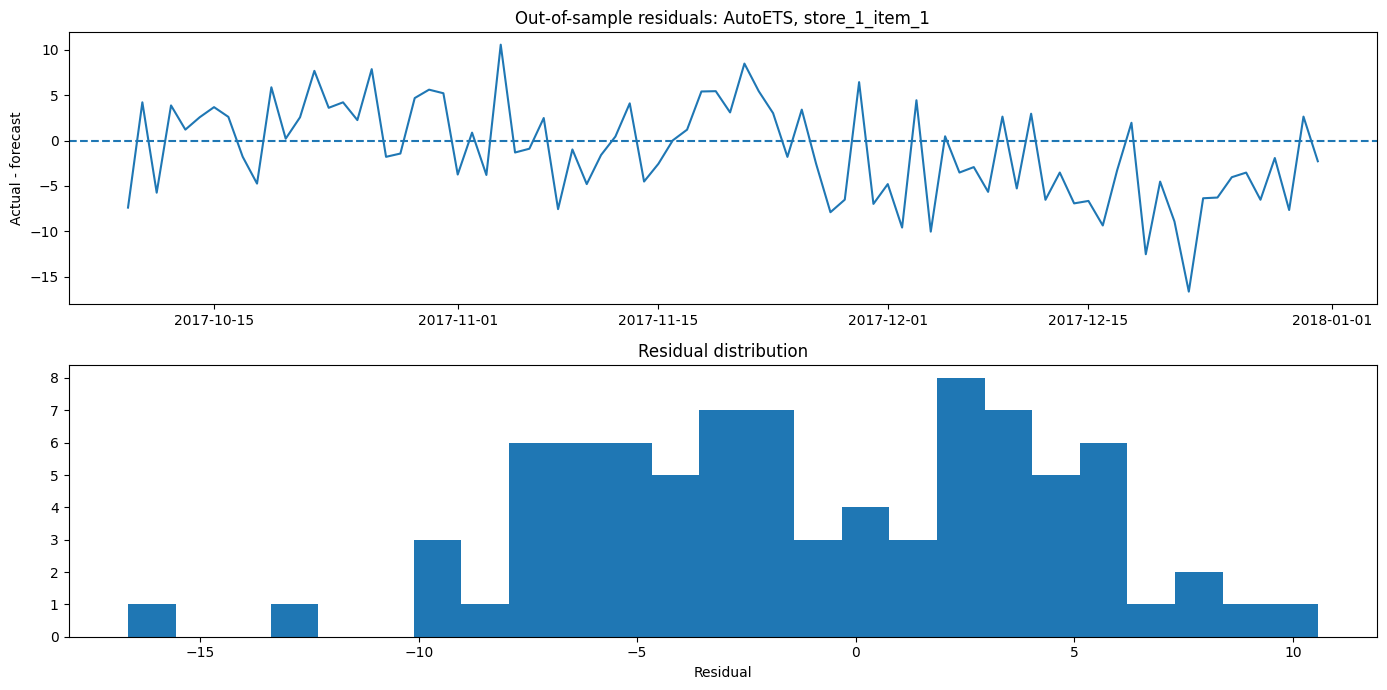

In [ ]:
best_model = metrics_df.iloc[0]['model']
example_id = 'store_1_item_1'
resid_df = cv_df.loc[cv_df['unique_id'].eq(example_id), ['ds', 'y', best_model]].copy()
resid_df = resid_df.sort_values('ds')
assert not resid_df['ds'].duplicated().any(), 'Expected non-overlapping CV windows'
resid_df['residual'] = resid_df['y'] - resid_df[best_model]

print('Best model:', best_model)
print('Example series:', example_id)
print('N OOS residuals:', len(resid_df))
print('Mean residual:', resid_df['residual'].mean())

# H0: mean residual = 0 (interpret carefully: residuals are time-dependent).
t_stat, t_p = stats.ttest_1samp(resid_df['residual'], popmean=0.0, nan_policy='omit')
print(f't-test (descriptive): t={t_stat:.3f}, p={t_p:.4g}')

lags = [7, 14, 21, 28]
lb = acorr_ljungbox(resid_df['residual'].dropna(), lags=lags, return_df=True)
display(lb)

jb = stats.jarque_bera(resid_df['residual'].dropna())
print(f'Jarque-Bera: statistic={jb.statistic:.3f}, p={jb.pvalue:.4g}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(resid_df['ds'], resid_df['residual'])
axes[0].axhline(0, linestyle='--')
axes[0].set_title(f'Out-of-sample residuals: {best_model}, {example_id}')
axes[0].set_ylabel('Actual - forecast')
axes[1].hist(resid_df['residual'].dropna(), bins=25)
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

## 4. Прогнозные интервалы AutoETS

Отдельно демонстрируется построение prediction intervals для `AutoETS`.

Этот раздел показывает работу с неопределённостью прогноза, но **не используется для выбора победителя**. Финальное сравнение моделей основано на одной и той же out-of-sample таблице метрик.


,index,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95
0,0,store_1_item_1,2018-01-01,13.623658,7.182314,9.411890,17.835426,20.065002
1,1,store_1_item_1,2018-01-02,15.589508,9.104237,11.349017,19.830000,22.074780
2,2,store_1_item_1,2018-01-03,16.327225,9.794082,12.055432,20.599018,22.860369
3,3,store_1_item_1,2018-01-04,16.700665,10.117779,12.396347,21.004982,23.283548
4,4,store_1_item_1,2018-01-05,17.966633,11.326611,13.624955,22.308310,24.606655


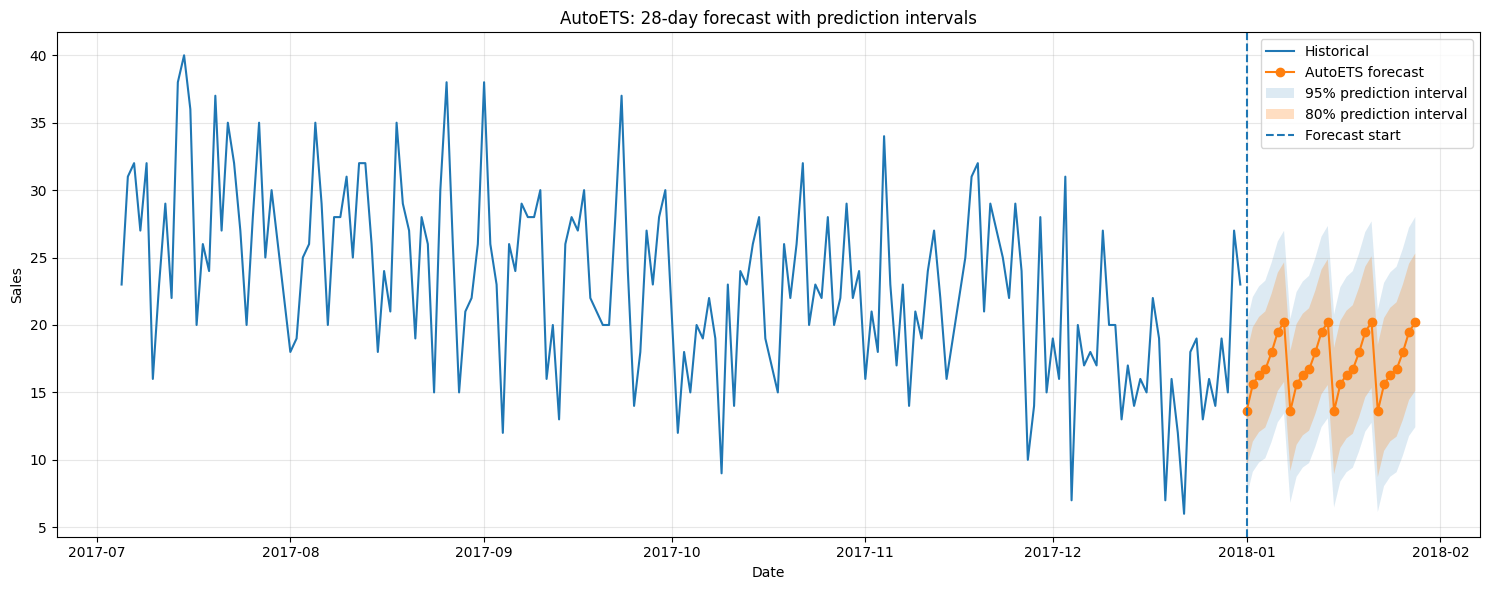

In [ ]:
example_train = df_stats[df_stats['unique_id'].eq(example_id)].copy()
pi_sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH)], freq='D', n_jobs=1)
forecast = pi_sf.forecast(df=example_train, h=HORIZON, level=[80, 95]).reset_index()
display(forecast.head())

fig, ax = plt.subplots(figsize=(15, 6))
hist = example_train.tail(180)
ax.plot(hist['ds'], hist['y'], label='Historical')
ax.plot(forecast['ds'], forecast['AutoETS'], marker='o', label='AutoETS forecast')
ax.fill_between(forecast['ds'], forecast['AutoETS-lo-95'], forecast['AutoETS-hi-95'], alpha=0.15, label='95% prediction interval')
ax.fill_between(forecast['ds'], forecast['AutoETS-lo-80'], forecast['AutoETS-hi-80'], alpha=0.25, label='80% prediction interval')
ax.axvline(forecast['ds'].min(), linestyle='--', label='Forecast start')
ax.set_title('AutoETS: 28-day forecast with prediction intervals')
ax.set_xlabel('Date'); ax.set_ylabel('Sales'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'task2_probabilistic_forecast_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()

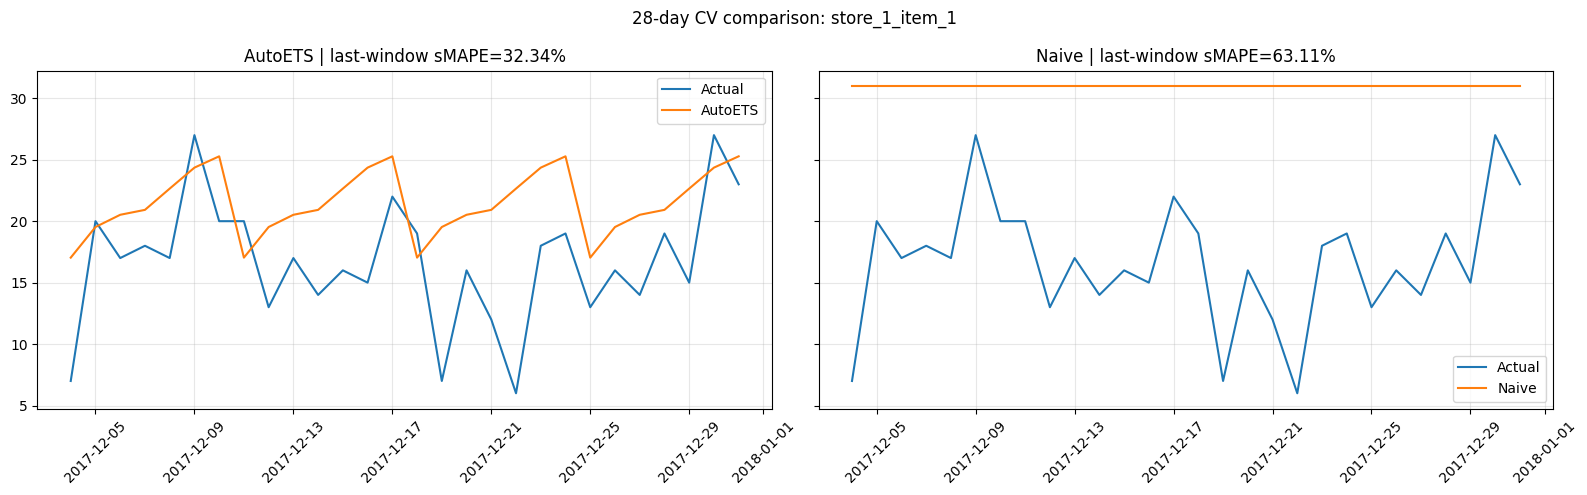

In [ ]:
# Сравнение лучшей и худшей модели на последнем CV-окне выбранного ряда.
best_model = metrics_df.iloc[0]['model']
worst_model = metrics_df.iloc[-1]['model']
last_cutoff = cv_df.loc[cv_df['unique_id'].eq(example_id), 'cutoff'].max()
plot_df = cv_df[(cv_df['unique_id'].eq(example_id)) & (cv_df['cutoff'].eq(last_cutoff))].sort_values('ds')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, model in zip(axes, [best_model, worst_model]):
    ax.plot(plot_df['ds'], plot_df['y'], label='Actual')
    ax.plot(plot_df['ds'], plot_df[model], label=model)
    score = smape_pct(plot_df['y'], plot_df[model])
    ax.set_title(f'{model} | last-window sMAPE={score:.2f}%')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3); ax.legend()
plt.suptitle(f'28-day CV comparison: {example_id}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'task2_forecast_comparison_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('FINAL TASK 2 SUMMARY')
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print()
print('Interpretation rule: the best model is the one with the lowest out-of-sample sMAPE on the same 3×28-day backtest.')
print('Do not call 100-sMAPE an accuracy score.')

FINAL TASK 2 SUMMARY
        model  sMAPE_%    MAE   RMSE
      AutoETS   16.978  8.329 10.888
    AutoTheta   17.032  8.362 10.931
    AutoARIMA   18.651  9.092 11.765
SeasonalNaive   21.067 10.499 13.982
        Naive   25.089 13.929 18.250

Interpretation rule: the best model is the one with the lowest out-of-sample sMAPE on the same 3×28-day backtest.
Do not call 100-sMAPE an accuracy score.


## 5. Итоговые результаты

| Модель | sMAPE, % | MAE | RMSE |
|---|---:|---:|---:|
| **AutoETS** | **16.978** | **8.329** | **10.888** |
| AutoTheta | 17.032 | 8.362 | 10.931 |
| AutoARIMA | 18.651 | 9.092 | 11.765 |
| SeasonalNaive | 21.067 | 10.499 | 13.982 |
| Naive | 25.089 | 13.929 | 18.250 |

В рамках выбранной схемы backtesting минимальную sMAPE показывает **AutoETS**. `AutoTheta` даёт очень близкий результат, тогда как оба baseline заметно уступают автоматическим статистическим моделям.

Для `store_1_item_1` Ljung–Box test показывает статистически значимую остаточную автокорреляцию на лагах 7–28, поэтому даже лучшая статистическая модель не описывает всю временную структуру выбранного ряда.

> Эти результаты используются как statistical benchmark в Task 3. Вывод относится именно к конфигурации `3 × 28`, `refit=False`; при другой схеме переобучения метрики могут измениться.
